<a href="https://colab.research.google.com/github/joanby/python-ml-course/blob/master/notebooks/T9%20-%203%20-%20Sistemas%20de%20recomendación-Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fuente:
- http://rasbt.github.io/mlxtend/user_guide/frequent_patterns/apriori/
- https://es.wikipedia.org/wiki/Algoritmo_apriori#:~:text=El%20algoritmo%20a%20priori%20es,para%20generar%20reglas%20de%20asociaci%C3%B3n


## Algoritmo Apriori

El algoritmo a priori es un algoritmo utilizado en minería de datos, sobre bases de datos transaccionales, que permite encontrar de forma eficiente "<u>**conjuntos de ítems frecuentes**</u>", los cuales sirven de base para generar <u>**reglas de asociación**</u>

image.png

Encontrada en los datos de ventas de un supermercado, indicaría que un consumidor que compra cebollas y verdura a la vez, es probable que compre también carne.

Esta información se puede utilizar como base para tomar decisiones sobre marketing como precios promocionales para ciertos productos o dónde ubicar estos dentro del supermercado. Además del ejemplo anterior aplicado al análisis de la cesta de la compra, hoy en día, las reglas de asociación también son de aplicación en otras muchas áreas como el web mining, la detección de intrusos o la bioinformática.

# Ejemplo Teórico

Asumamos una base de datos de transacciones donde cada transacción es un conjunto de productos que son comprados juntos. Por conveniencia, productos como "mantequilla" y "pan" son representados por números. Sea la base de datos representados por los siguientes conjuntos



1- Cebolla

2- Carne Hamburguesa

3- Queso

4- Pan

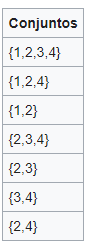

Usaremos Apriori para determinar los conjuntos de ítems frecuentes de la base de datos. Definamos que un ítem es frecuente si aparece en al menos 3 transacciones de la base da datos, por lo que <u>***3 será el umbral de confianza***.</u>

El primer paso es contar el número de ocurrencias, llamado la confianza, de cada ítem separadamente, escaneando la base una primera vez. Se obtienen los siguientes resultados



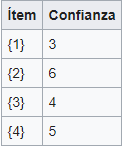

Todos los conjuntos de tamaño 1 tienen confianza de al menos 3, por lo que todos son frecuentes.

El próximo paso es generar la lista de todos los pares de ítems frecuentes. Por ejemplo, considerando que el par {1,2} de la primera tabla del ejemplo, muestra que los ítems 1 y 2 aparecen juntos en tres de los conjuntos de ítems originales de la base de datos, definimos que {1,2} tiene una confianza de tres.

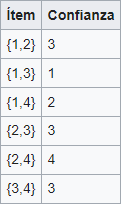

Los pares {1,2} , {2,3} , {2,4} y {3,4} tienen una confianza mayor que 3, por lo que son frecuentes; el resto se considera que no lo son.

Como {1,3} y {1,4} no son frecuentes, cualquier conjunto que contenga estos pares es considerado infrecuente. De esta manera se pueden podar los conjuntos. Analizando los conjuntos de ítems frecuentes de tamaño 3 se obtiene

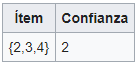

En este ejemplo, no hay triplos frecuentes, ya que {2,3,4} se encuentra por debajo del valor de confianza. Hemos determinado entonces los conjuntos frecuentes de ítems en la base de datos.

**Condición de finalización**

El algoritmo Apriori utiliza un enfoque iterativo para generar reglas de asociación a partir de los datos de entrada. La condición de finalización del algoritmo Apriori se basa en dos factores:

- Soporte mínimo: se establece un valor mínimo para el soporte que debe tener un conjunto de ítems para ser considerado un conjunto frecuente. Si un conjunto de ítems no cumple con el soporte mínimo, entonces no será considerado en las siguientes iteraciones.

- Generación de reglas: una vez que se han identificado todos los conjuntos frecuentes con el soporte mínimo, el algoritmo comienza a generar reglas de asociación entre ellos. Si no se pueden generar más reglas, el algoritmo se detiene.

En resumen, el algoritmo Apriori finaliza cuando no se pueden generar más reglas de asociación o cuando todos los conjuntos de ítems han sido evaluados y no cumplen con el soporte mínimo requerido.

# Ejemplo 1: Generación de conjuntos de elementos frecuentes



La función apriori espera datos en un DataFrame de pandas codificado en one-hot. Supongamos que tenemos los siguientes datos de transacción:

In [ ]:
dataset = [['Milk', 'Onion', 'Nutmeg', 'Kidney Beans', 'Eggs', 'Yogurt'],
           ['Dill', 'Onion', 'Nutmeg', 'Kidney Beans', 'Eggs', 'Yogurt'],
           ['Milk', 'Apple', 'Kidney Beans', 'Eggs'],
           ['Milk', 'Unicorn', 'Corn', 'Kidney Beans', 'Yogurt'],
           ['Corn', 'Onion', 'Onion', 'Kidney Beans', 'Ice cream', 'Eggs']]

El <u>**TransactionEncoder**</u> es una herramienta de la biblioteca mlxtend en Python, utilizada para transformar datos de transacciones, que suelen estar en formato de listas de listas, en una matriz de formato one-hot encoding adecuada para algoritmos de análisis de asociación como Apriori. Este proceso de transformación es esencial para convertir datos de transacciones, donde cada transacción es una lista de ítems comprados juntos, en un formato que se puede analizar fácilmente.

Podemos transformarlo al formato correcto mediante el TransactionEncoder de la siguiente manera:

In [ ]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)
df

,Apple,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Unicorn,Yogurt
0,False,False,False,True,False,True,True,True,True,False,True
1,False,False,True,True,False,True,False,True,True,False,True
2,True,False,False,True,False,True,True,False,False,False,False
3,False,True,False,False,False,True,True,False,False,True,True
4,False,True,False,True,True,True,False,False,True,False,False


In [ ]:
from mlxtend.frequent_patterns import apriori
apriori(df, min_support=0.6)

,support,itemsets
0,0.8,(3)
1,1.0,(5)
2,0.6,(6)
3,0.6,(8)
4,0.6,(10)
5,0.8,"(3, 5)"
6,0.6,"(8, 3)"
7,0.6,"(5, 6)"
8,0.6,"(8, 5)"
9,0.6,"(10, 5)"


- La columna `support` indica la frecuencia relativa (o soporte) de cada conjunto de ítems en el conjunto de datos. <u>**Un valor de soporte de 0.6**, por ejemplo, significa que el conjunto de ítems correspondiente aparece en el 60% de las transacciones.</u>

- La columna `itemsets` muestra los conjuntos de ítems que aparecen con frecuencia en el conjunto de datos y que cumplen con el umbral de soporte mínimo especificado. Cada fila representa un conjunto de ítems frecuentes, y los números entre paréntesis representan los identificadores de los ítems individuales.

Por defecto, apriori devuelve los índices de columna de los ítems, lo cual puede ser útil en operaciones posteriores como la minería de reglas de asociación. Para mejorar la legibilidad, podemos establecer <u>**use_colnames=True**</u> para convertir estos valores enteros en los nombres de ítems respectivos:

In [ ]:
apriori(df, min_support=0.6, use_colnames=True)


,support,itemsets
0,0.8,(Eggs)
1,1.0,(Kidney Beans)
2,0.6,(Milk)
3,0.6,(Onion)
4,0.6,(Yogurt)
5,0.8,"(Kidney Beans, Eggs)"
6,0.6,"(Onion, Eggs)"
7,0.6,"(Kidney Beans, Milk)"
8,0.6,"(Kidney Beans, Onion)"
9,0.6,"(Kidney Beans, Yogurt)"


# Example 2: Selecting and Filtering Results

La ventaja de trabajar con DataFrames de pandas es que podemos usar sus convenientes características para filtrar los resultados. Por ejemplo, supongamos que solo estamos interesados en conjuntos de ítems de longitud 2 que tienen un soporte de al menos el 80 por ciento. Primero, creamos los conjuntos de ítems frecuentes mediante apriori y añadimos una nueva columna que almacena la longitud de cada conjunto de ítems:

In [ ]:
frequent_itemsets = apriori(df, min_support=0.6, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
frequent_itemsets

,support,itemsets,length
0,0.8,(Eggs),1
1,1.0,(Kidney Beans),1
2,0.6,(Milk),1
3,0.6,(Onion),1
4,0.6,(Yogurt),1
5,0.8,"(Kidney Beans, Eggs)",2
6,0.6,"(Onion, Eggs)",2
7,0.6,"(Kidney Beans, Milk)",2
8,0.6,"(Kidney Beans, Onion)",2
9,0.6,"(Kidney Beans, Yogurt)",2


Luego, podemos seleccionar los resultados que satisfacen nuestros criterios deseados de la siguiente manera:

In [ ]:
frequent_itemsets[ (frequent_itemsets['length'] == 2) &
                   (frequent_itemsets['support'] >= 0.8) ]

,support,itemsets,length
5,0.8,"(Kidney Beans, Eggs)",2


De manera similar, utilizando la API de Pandas, podemos seleccionar entradas basadas en la columna "itemsets":



In [ ]:
frequent_itemsets[ frequent_itemsets['itemsets'] == {'Onion', 'Eggs'} ]


,support,itemsets,length
6,0.6,"(Onion, Eggs)",2


**Frozensets**

https://www.youtube.com/watch?v=BN8IM1wXgPc

Ten en cuenta que <u>las entradas en la columna "itemsets" son del tipo frozenset</u>, que es un tipo incorporado en Python que es similar a un set de Python pero inmutable, <u>**lo que lo hace más eficiente para ciertas operaciones de consulta o comparación**</u> (https://docs.python.org/3.6/library/stdtypes.html#frozenset). Dado que los frozensets son conjuntos, el orden de los ítems no importa. Es decir, la consulta

- frequent_itemsets[ frequent_itemsets['itemsets'] == {'Onion', 'Eggs'} ]

es equivalente a cualquiera de las siguientes tres

- frequent_itemsets[ frequent_itemsets['itemsets'] == {'Eggs', 'Onion'} ]

- frequent_itemsets[ frequent_itemsets['itemsets'] == frozenset(('Eggs', 'Onion')) ]

- frequent_itemsets[ frequent_itemsets['itemsets'] == frozenset(('Onion', 'Eggs')) ]

# Example 3: Working with Sparse Representations

**Matrices dispersas**

Las matrices dispersas son aquellas en las que la mayoría de los registros son cero. Este hecho hace que sea posible más eficaz trabajar con ellas guardando sólo las posiciones de los valores de los elementos distintos de cero. Lo que supone un importante ahorro en el a la hora de almacenar estas matrices en memoria o disco.

Otro problema de las matrices dispersas es a la hora de utilizarlas en operaciones matemáticas. Unas matrices muy grandes pueden no caber en memoria, haciendo más complicado llevar a cabo las operaciones.

Para ahorrar memoria, es posible que quieras representar tus datos de transacciones en formato disperso (sparse format). Esto es especialmente útil si tienes muchos productos y transacciones pequeñas.
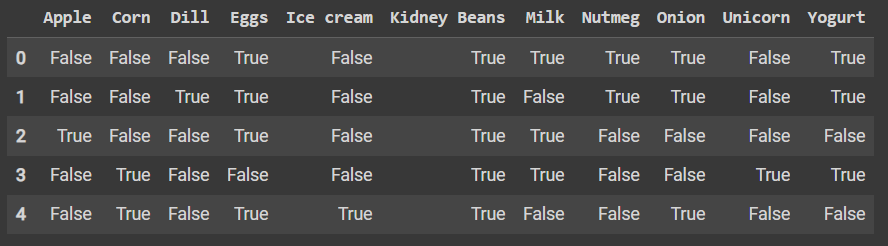

In [ ]:
oht_ary = te.fit(dataset).transform(dataset, sparse=True)
sparse_df = pd.DataFrame.sparse.from_spmatrix(oht_ary, columns=te.columns_)
sparse_df

,Apple,Corn,Dill,Eggs,Ice cream,Kidney Beans,Milk,Nutmeg,Onion,Unicorn,Yogurt
0,0,0,0,1,0,True,1,1,1,0,1
1,0,0,1,1,0,True,0,1,1,0,1
2,1,0,0,1,0,True,1,0,0,0,0
3,0,1,0,0,0,True,1,0,0,1,1
4,0,1,0,1,1,True,0,0,1,0,0


In [ ]:
sparsity = float(len(oht_ary.nonzero()[0]))
sparsity /=(oht_ary.shape[0]*oht_ary.shape[1])
sparsity *= 100
print("Coeficiente de sparsedad: {:4.2f}%".format(sparsity))

Coeficiente de sparsedad: 47.27%


El <u>"**coeficiente de esparcimiento**" (o sparsity, en inglés) indica qué porcentaje de los elementos en una matriz son ceros</u>, lo que refleja cuán "vacía" o dispersa está la matriz.

En el contexto de los datos de transacciones, una matriz dispersa significa que <u>hay muchas transacciones en las que no se compran la mayoría de los productos</u> (es decir, la mayoría de las entradas en la matriz son cero porque el producto correspondiente no se incluyó en la transacción).

Un valor alto de esparcidad (sparsity) indica que se han comprado pocos productos en relación con el número total de productos disponibles.

Por ejemplo, si tu coeficiente de esparcidad es del 95%, significa que solo el 5% de las posibles compras de productos (elementos no cero en la matriz) ocurrieron realmente, y el 95% de las posibles compras no ocurrieron (elementos cero en la matriz). Este es un indicador claro de que en la mayoría de las transacciones se compraron relativamente pocos productos.

En el contexto de un análisis de cesta de compras o de datos de transacciones, un alto coeficiente de esparcidad es común y esperado, ya que los clientes suelen comprar solo un pequeño subconjunto de los productos disponibles en cada visita.

Processing 21 combinations | Sampling itemset size 3

In [ ]:
apriori(sparse_df, min_support=0.6, use_colnames=True)

,support,itemsets
0,0.8,(Eggs)
1,1.0,(Kidney Beans)
2,0.6,(Milk)
3,0.6,(Onion)
4,0.6,(Yogurt)
5,0.8,"(Kidney Beans, Eggs)"
6,0.6,"(Onion, Eggs)"
7,0.6,"(Kidney Beans, Milk)"
8,0.6,"(Kidney Beans, Onion)"
9,0.6,"(Kidney Beans, Yogurt)"
